# RS Variation Comparison Plots

This notebook compares refrigerated-space infiltration variations for room temperature, refrigerant mass flow rate, and system COP over time.


In [15]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import pandas as pd

# Locate project root when running from either the project root or visualization folder.
project_root = Path.cwd()
if not (project_root / "outputs").exists():
    project_root = project_root.parent

output_dir = project_root / "outputs"
figure_dir = output_dir / "comparison_plots"
figure_dir.mkdir(exist_ok=True)

# Publication-style plot settings based on the provided reference code.
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "dejavuserif",
    "font.size": 22,
    "axes.labelsize": 28,
    "axes.titlesize": 24,
    "axes.linewidth": 1.6,
    "xtick.labelsize": 22,
    "ytick.labelsize": 22,
    "legend.fontsize": 18,
    "legend.title_fontsize": 22,
    "figure.dpi": 140,
    "savefig.dpi": 300,
    "axes.grid": False,
})

# Colorblind-friendly palettes based on the Okabe-Ito color set.
comparison_palettes = {
    "door_frequency": ["#0072B2", "#E69F00", "#009E73"],  # blue, orange, green
    "door_time": ["#56B4E9", "#D55E00", "#CC79A7"],       # sky blue, vermillion, purple
    "dock_door_time": ["#332288", "#88CCEE", "#DDCC77"],  # indigo, cyan, sand
    "load": ["#0072B2", "#D55E00", "#009E73"],            # blue, vermillion, green
}


def style_axes(ax):
    ax.tick_params(which="major", direction="in", top=True, right=True, length=8, width=1.4)
    ax.tick_params(which="minor", direction="in", top=True, right=True, length=4, width=1.1)
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_linewidth(1.6)


In [16]:
CASE_RE = re.compile(
    r"^(?P<space>RS|LD)_Infiltration_Qvc(?P<qvc>[0-9]+(?:p[0-9]+)?)_"
    r"Qld(?P<qld>[0-9]+(?:p[0-9]+)?)_"
    r"(?P<openings_per_hour>[0-9]+)_door_"
    r"(?P<door_open_s>[0-9]+)s"
    r"(?:_(?P<version>[0-9]+))?\.csv$"
)


def parse_number(value):
    return float(value.replace("p", "."))


def discover_cases(output_dir):
    rows = []
    for path in sorted(output_dir.glob("*_Infiltration_Qvc*_Qld*_door_*s*.csv")):
        match = CASE_RE.match(path.name)
        if not match:
            continue
        version = match.group("version")
        rows.append({
            "space": match.group("space"),
            "qvc": parse_number(match.group("qvc")),
            "qld": parse_number(match.group("qld")),
            "openings_per_hour": int(match.group("openings_per_hour")),
            "door_open_s": int(match.group("door_open_s")),
            "version": int(version) if version is not None else 0,
            "modified": path.stat().st_mtime,
            "path": path,
        })
    if not rows:
        raise FileNotFoundError(f"No RS/LD infiltration CSV files found in {output_dir}")

    cases = pd.DataFrame(rows)
    cases = cases.sort_values([
        "space", "qvc", "qld", "openings_per_hour", "door_open_s", "version", "modified"
    ])

    # Keep one file per parameter set. This handles both unversioned files and _1/_2 suffixes.
    cases = cases.drop_duplicates(
        ["space", "qvc", "qld", "openings_per_hour", "door_open_s"],
        keep="last",
    ).reset_index(drop=True)
    return cases


cases = discover_cases(output_dir)
cases


,space,qvc,qld,openings_per_hour,door_open_s,version,modified,path
0,LD,100.0,25.0,2,1080,1,1.781145e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
1,LD,100.0,25.0,2,1200,1,1.781145e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
2,LD,100.0,25.0,2,1320,1,1.781145e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
3,RS,100.0,12.5,4,12,1,1.781074e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
4,RS,100.0,12.5,4,20,1,1.781074e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
5,RS,100.0,12.5,4,30,1,1.781074e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
6,RS,100.0,15.0,4,12,1,1.781189e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
7,RS,100.0,15.0,4,20,1,1.781190e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
8,RS,100.0,15.0,4,30,1,1.781190e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
9,RS,100.0,20.0,4,12,1,1.781189e+09,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


In [17]:
PLOT_COLUMNS = [
    ("room_c", r"$T_{room}$ ($^\circ$C)"),
    ("m_ref_kg_s", r"$\dot{m}_{ref}$ (kg/s)"),
    ("cop_system", "COP"),
]

DOCK_PLOT_COLUMNS = [
    ("dock_c", r"$T_{dock}$ ($^\circ$C)"),
    ("m_ref_kg_s", r"$\dot{m}_{ref}$ (kg/s)"),
    ("cop_system", "COP"),
]


def select_cases(space=None, qvc=None, qld=None, openings_per_hour=None, door_open_s=None):
    selected = cases.copy()
    if space is not None:
        selected = selected[selected["space"] == space]
    if qvc is not None:
        selected = selected[selected["qvc"] == float(qvc)]
    if qld is not None:
        selected = selected[selected["qld"] == float(qld)]
    if openings_per_hour is not None:
        selected = selected[selected["openings_per_hour"] == int(openings_per_hour)]
    if door_open_s is not None:
        selected = selected[selected["door_open_s"] == int(door_open_s)]
    return selected.sort_values(["space", "qvc", "qld", "openings_per_hour", "door_open_s"])


def read_timeseries(path, plot_columns=PLOT_COLUMNS):
    metric_columns = [column for column, _ in plot_columns]
    usecols = ["time_s", *metric_columns]
    df = pd.read_csv(path, usecols=lambda col: col in usecols)
    missing = sorted(set(usecols) - set(df.columns))
    if missing:
        raise ValueError(f"{path.name} is missing columns: {missing}")
    df = df[usecols].apply(pd.to_numeric, errors="coerce").dropna()
    df["time_min"] = df["time_s"] / 60.0
    return df


def format_load(value):
    return f"{value:g}"


def plot_timeseries_comparison(selected, label_func, title, save_name, colors=None, plot_columns=PLOT_COLUMNS, xlim_min=None):
    if selected.empty:
        raise ValueError(f"No cases found for: {title}")

    fig, axes = plt.subplots(3, 1, figsize=(13.5, 13.0), sharex=True)
    colors = colors or comparison_palettes["load"]

    for case_index, (_, case) in enumerate(selected.iterrows()):
        df = read_timeseries(case["path"], plot_columns=plot_columns)
        label = label_func(case)
        color = colors[case_index % len(colors)]

        for ax, (column, ylabel) in zip(axes, plot_columns):
            ax.plot(df["time_min"], df[column], linewidth=2.8, color=color, label=label)
            ax.set_ylabel(ylabel)
            style_axes(ax)
            if xlim_min is not None:
                ax.set_xlim(0, xlim_min)

    legend = axes[0].legend(
        title="Condition",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        frameon=False,
        handlelength=2.5,
    )
    for line in legend.get_lines():
        line.set_linewidth(3.0)
    axes[-1].set_xlabel("Time (min)")
    fig.suptitle(title, fontsize=24)
    fig.align_ylabels(axes)
    fig.tight_layout(rect=[0, 0, 0.82, 0.95], h_pad=2.0)

    output_path = figure_dir / save_name
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    plt.show()


def plot_timeseries_matrix_comparison(selected, label_func, title, save_name, colors=None, plot_columns=PLOT_COLUMNS, xlim_min=None):
    if selected.empty:
        raise ValueError(f"No cases found for: {title}")

    selected = selected.reset_index(drop=True)
    colors = colors or comparison_palettes["door_frequency"]
    fig, axes = plt.subplots(
        len(plot_columns),
        len(selected),
        figsize=(19, 15.5),
        sharex=True,
        sharey="row",
    )

    if len(selected) == 1:
        axes = axes.reshape(len(plot_columns), 1)

    for col_index, (_, case) in enumerate(selected.iterrows()):
        df = read_timeseries(case["path"], plot_columns=plot_columns)
        label = label_func(case)

        for row_index, (column, ylabel) in enumerate(plot_columns):
            ax = axes[row_index, col_index]
            color = colors[col_index % len(colors)]
            ax.plot(df["time_min"], df[column], linewidth=2.8, color=color)
            if col_index == 0:
                ax.set_ylabel(ylabel)
            if row_index == 0:
                ax.set_title(label)
            if row_index == len(plot_columns) - 1:
                ax.set_xlabel("Time (min)")
            style_axes(ax)
            if xlim_min is not None:
                ax.set_xlim(0, xlim_min)

    fig.suptitle(title, fontsize=24)
    fig.align_ylabels(axes[:, 0])
    fig.tight_layout(rect=[0, 0, 1, 0.93], h_pad=2.0, w_pad=1.0)

    output_path = figure_dir / save_name
    fig.savefig(output_path, bbox_inches="tight")
    print(f"Saved {output_path}")
    plt.show()


## 1. Door Openings Per Hour

Compare 2, 4, and 8 door openings per hour using Qvc100, Qld25, and 12 s door-open time.


,qvc,qld,openings_per_hour,door_open_s,path
12,100.0,25.0,2,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
15,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
18,100.0,25.0,8,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_door_openings_per_hour_Qvc100_Qld25_12s.png


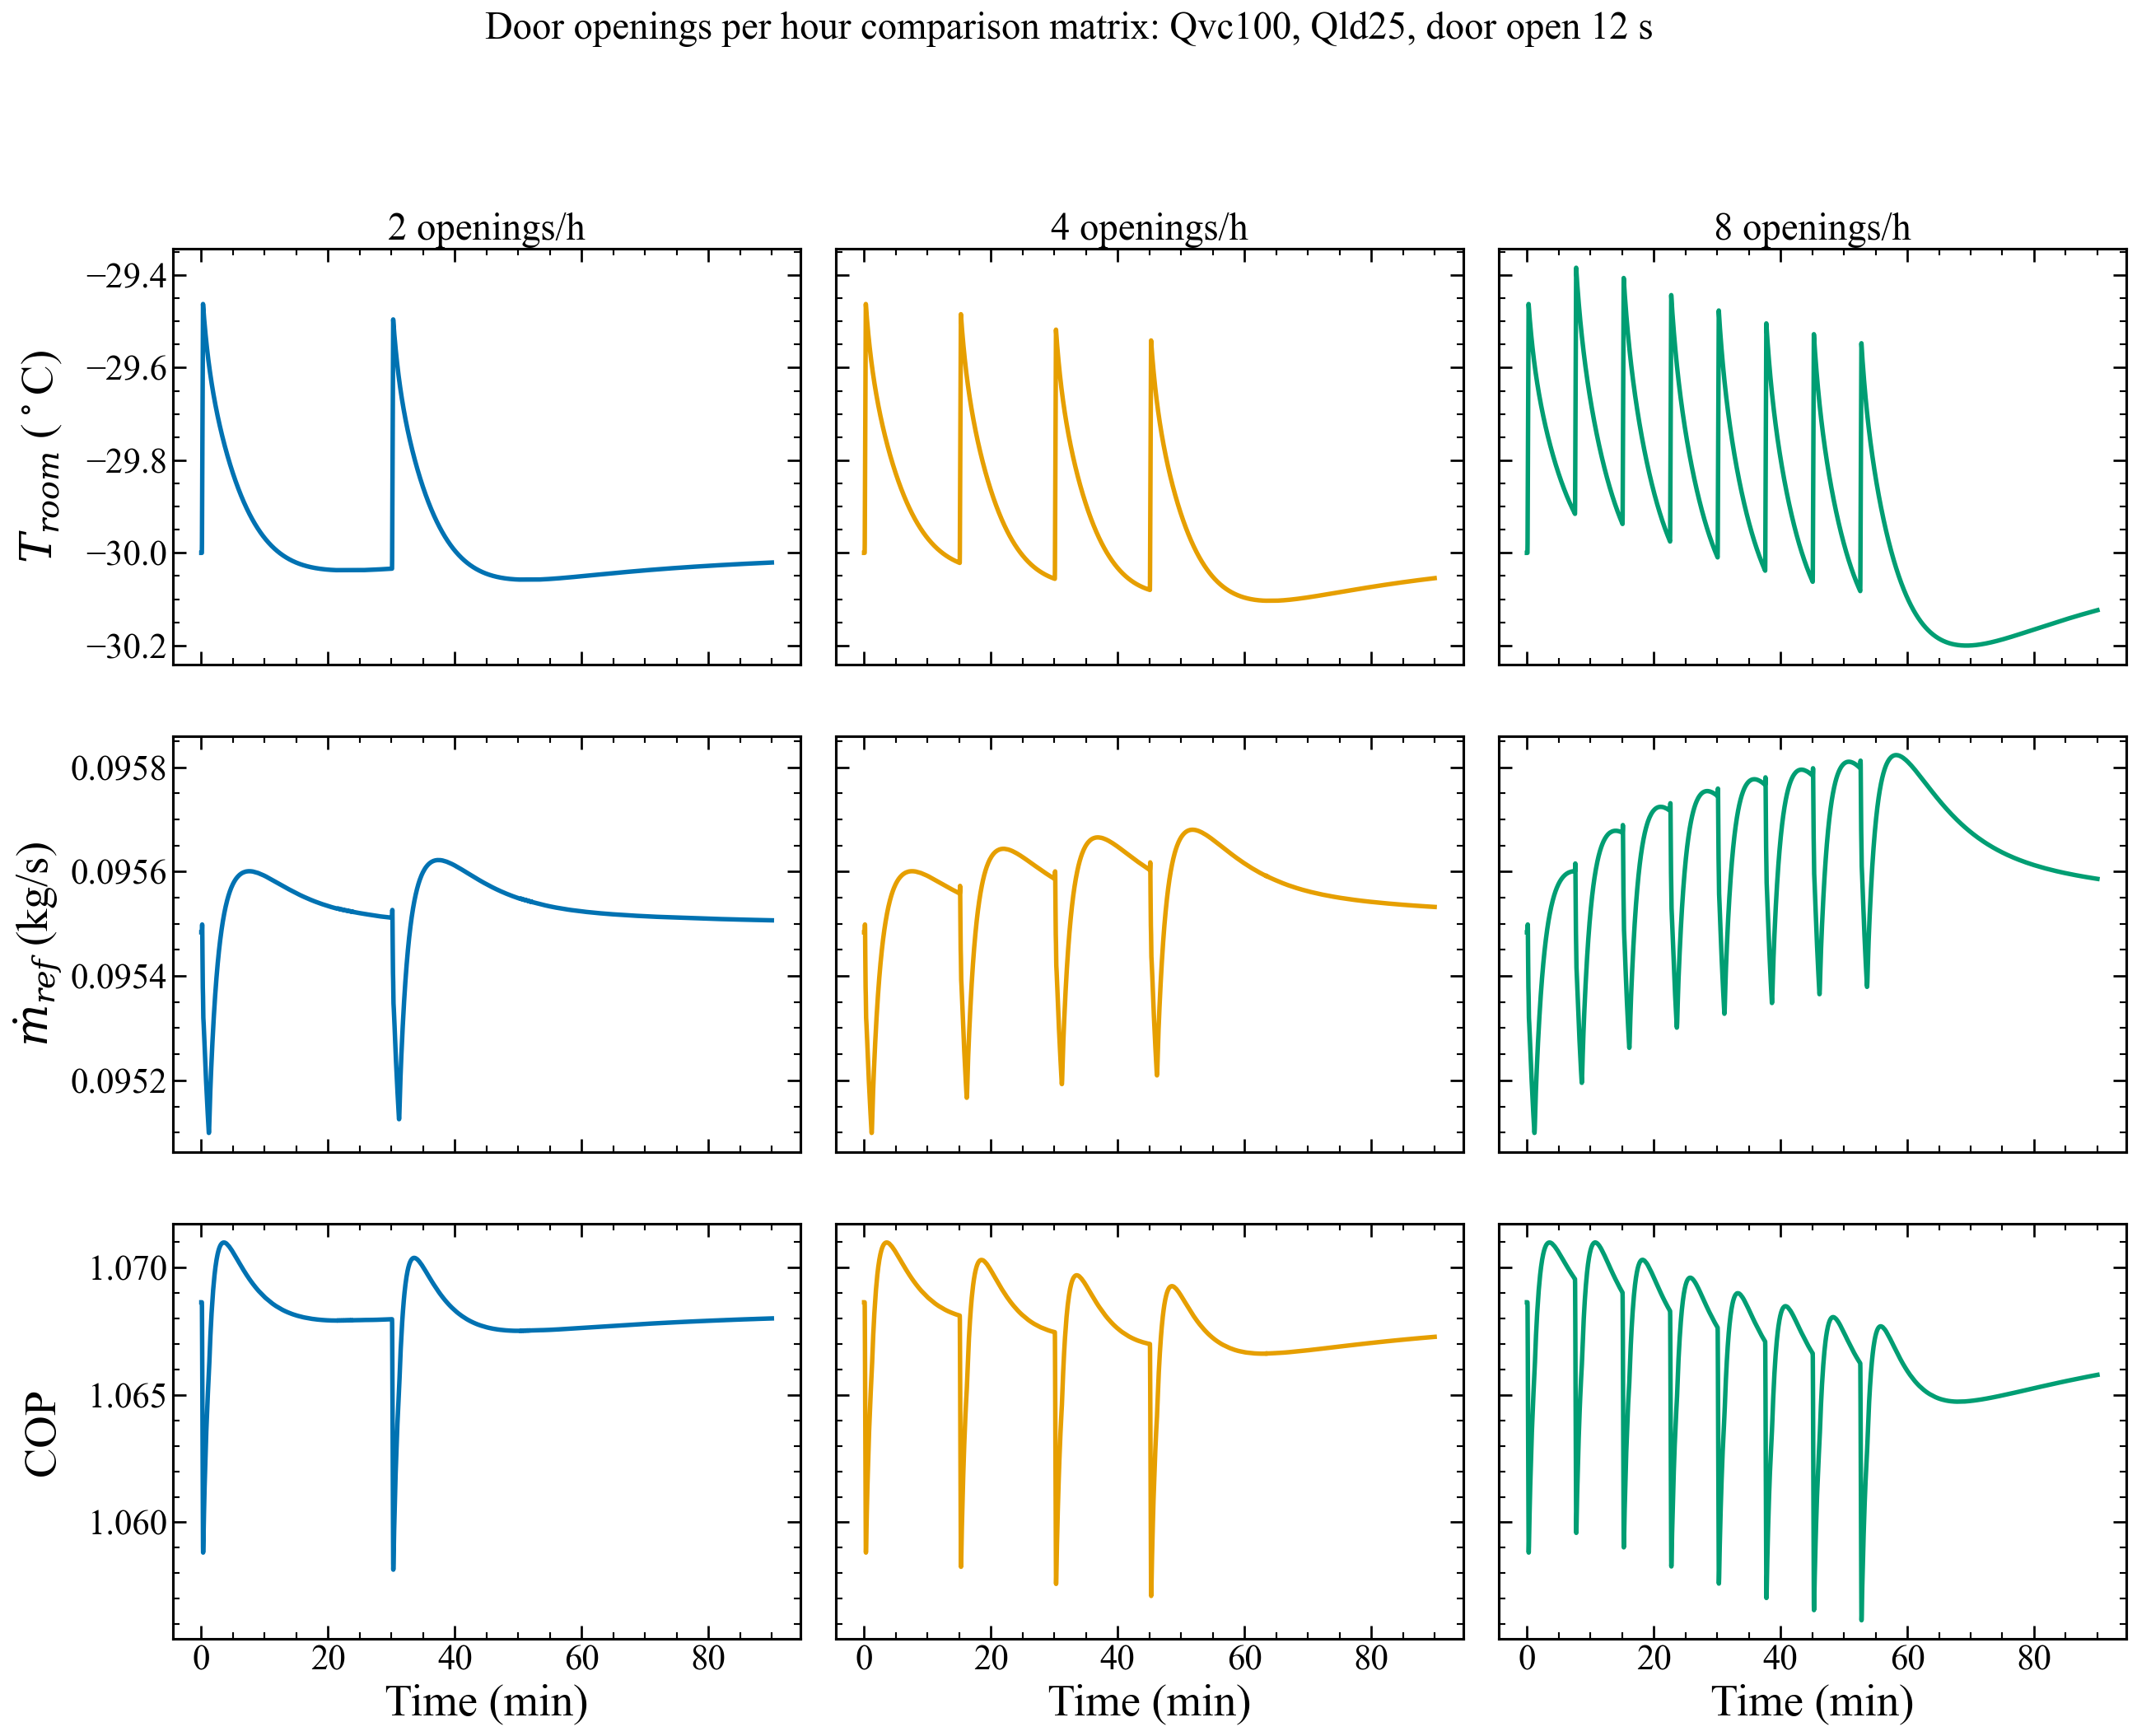

In [18]:
door_frequency_cases = select_cases(qvc=100, qld=25, door_open_s=12)
door_frequency_cases = door_frequency_cases[
    door_frequency_cases["openings_per_hour"].isin([2, 4, 8])
]

display(door_frequency_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_matrix_comparison(
    door_frequency_cases,
    label_func=lambda case: f"{int(case['openings_per_hour'])} openings/h",
    title="Door openings per hour comparison matrix: Qvc100, Qld25, door open 12 s",
    save_name="comparison_door_openings_per_hour_Qvc100_Qld25_12s.png",
    colors=comparison_palettes["door_frequency"],
)


## 2. Door-Open Time

Compare door-open durations using Qvc100, Qld25, and 4 door openings per hour.


,qvc,qld,openings_per_hour,door_open_s,path
15,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
16,100.0,25.0,4,20,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
17,100.0,25.0,4,30,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_door_open_time_Qvc100_Qld25_4openings.png


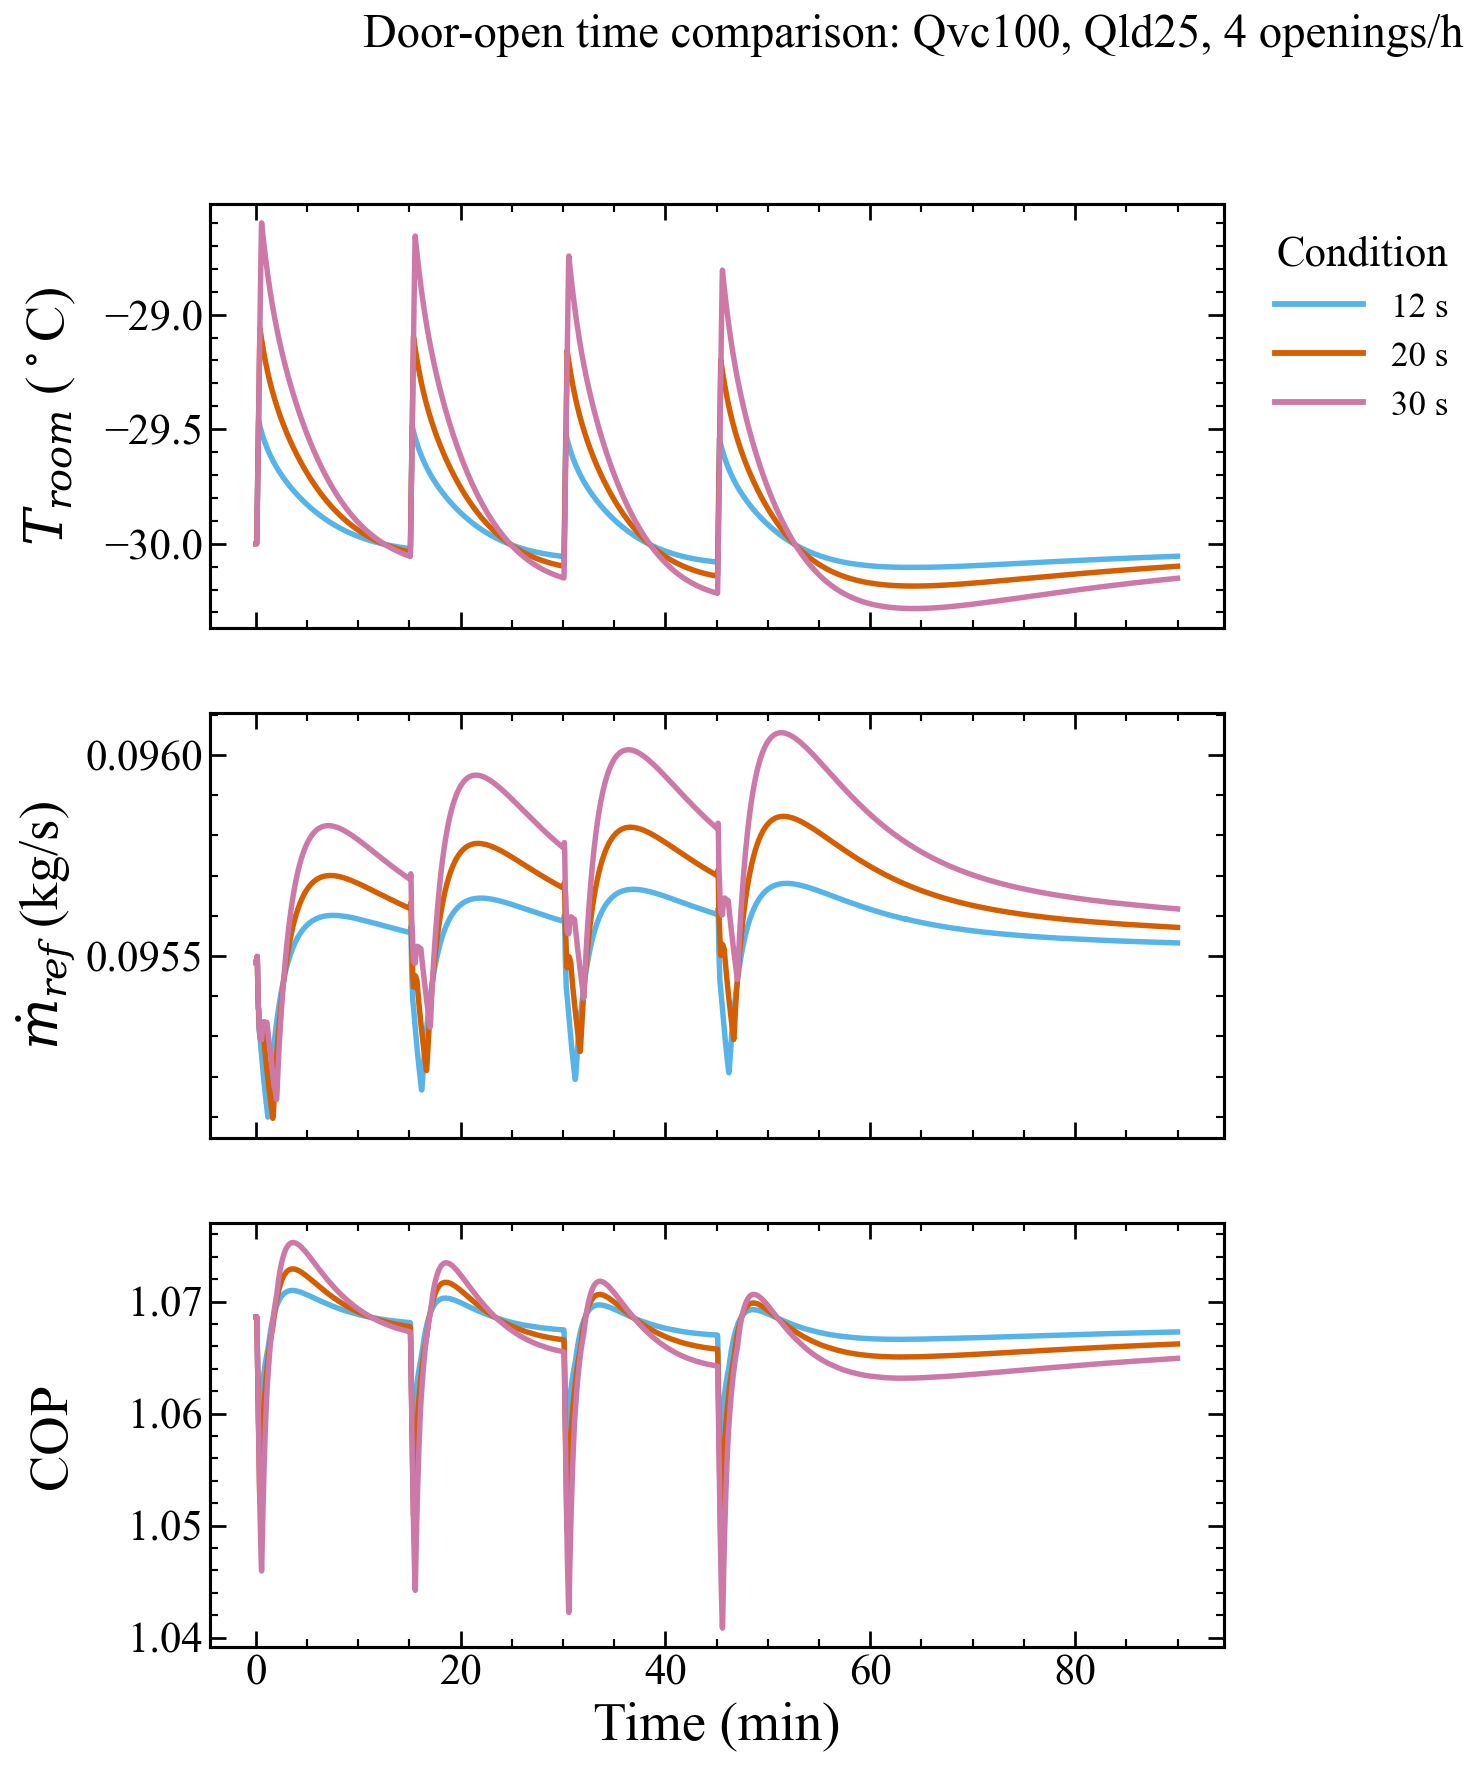

In [19]:
door_time_cases = select_cases(qvc=100, qld=25, openings_per_hour=4)
door_time_cases = door_time_cases[
    door_time_cases["door_open_s"].isin([12, 20, 30])
]

display(door_time_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_comparison(
    door_time_cases,
    label_func=lambda case: f"{int(case['door_open_s'])} s",
    title="Door-open time comparison: Qvc100, Qld25, 4 openings/h",
    save_name="comparison_door_open_time_Qvc100_Qld25_4openings.png",
    colors=comparison_palettes["door_time"],
)


## 3. Dock Door-Open Time

Compare dock-door open durations using LD Qvc100, Qld25, and 2 door openings per hour.


,space,qvc,qld,openings_per_hour,door_open_s,path
0,LD,100.0,25.0,2,1080,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
1,LD,100.0,25.0,2,1200,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
2,LD,100.0,25.0,2,1320,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_dock_door_open_time_Qvc100_Qld25_2openings.png


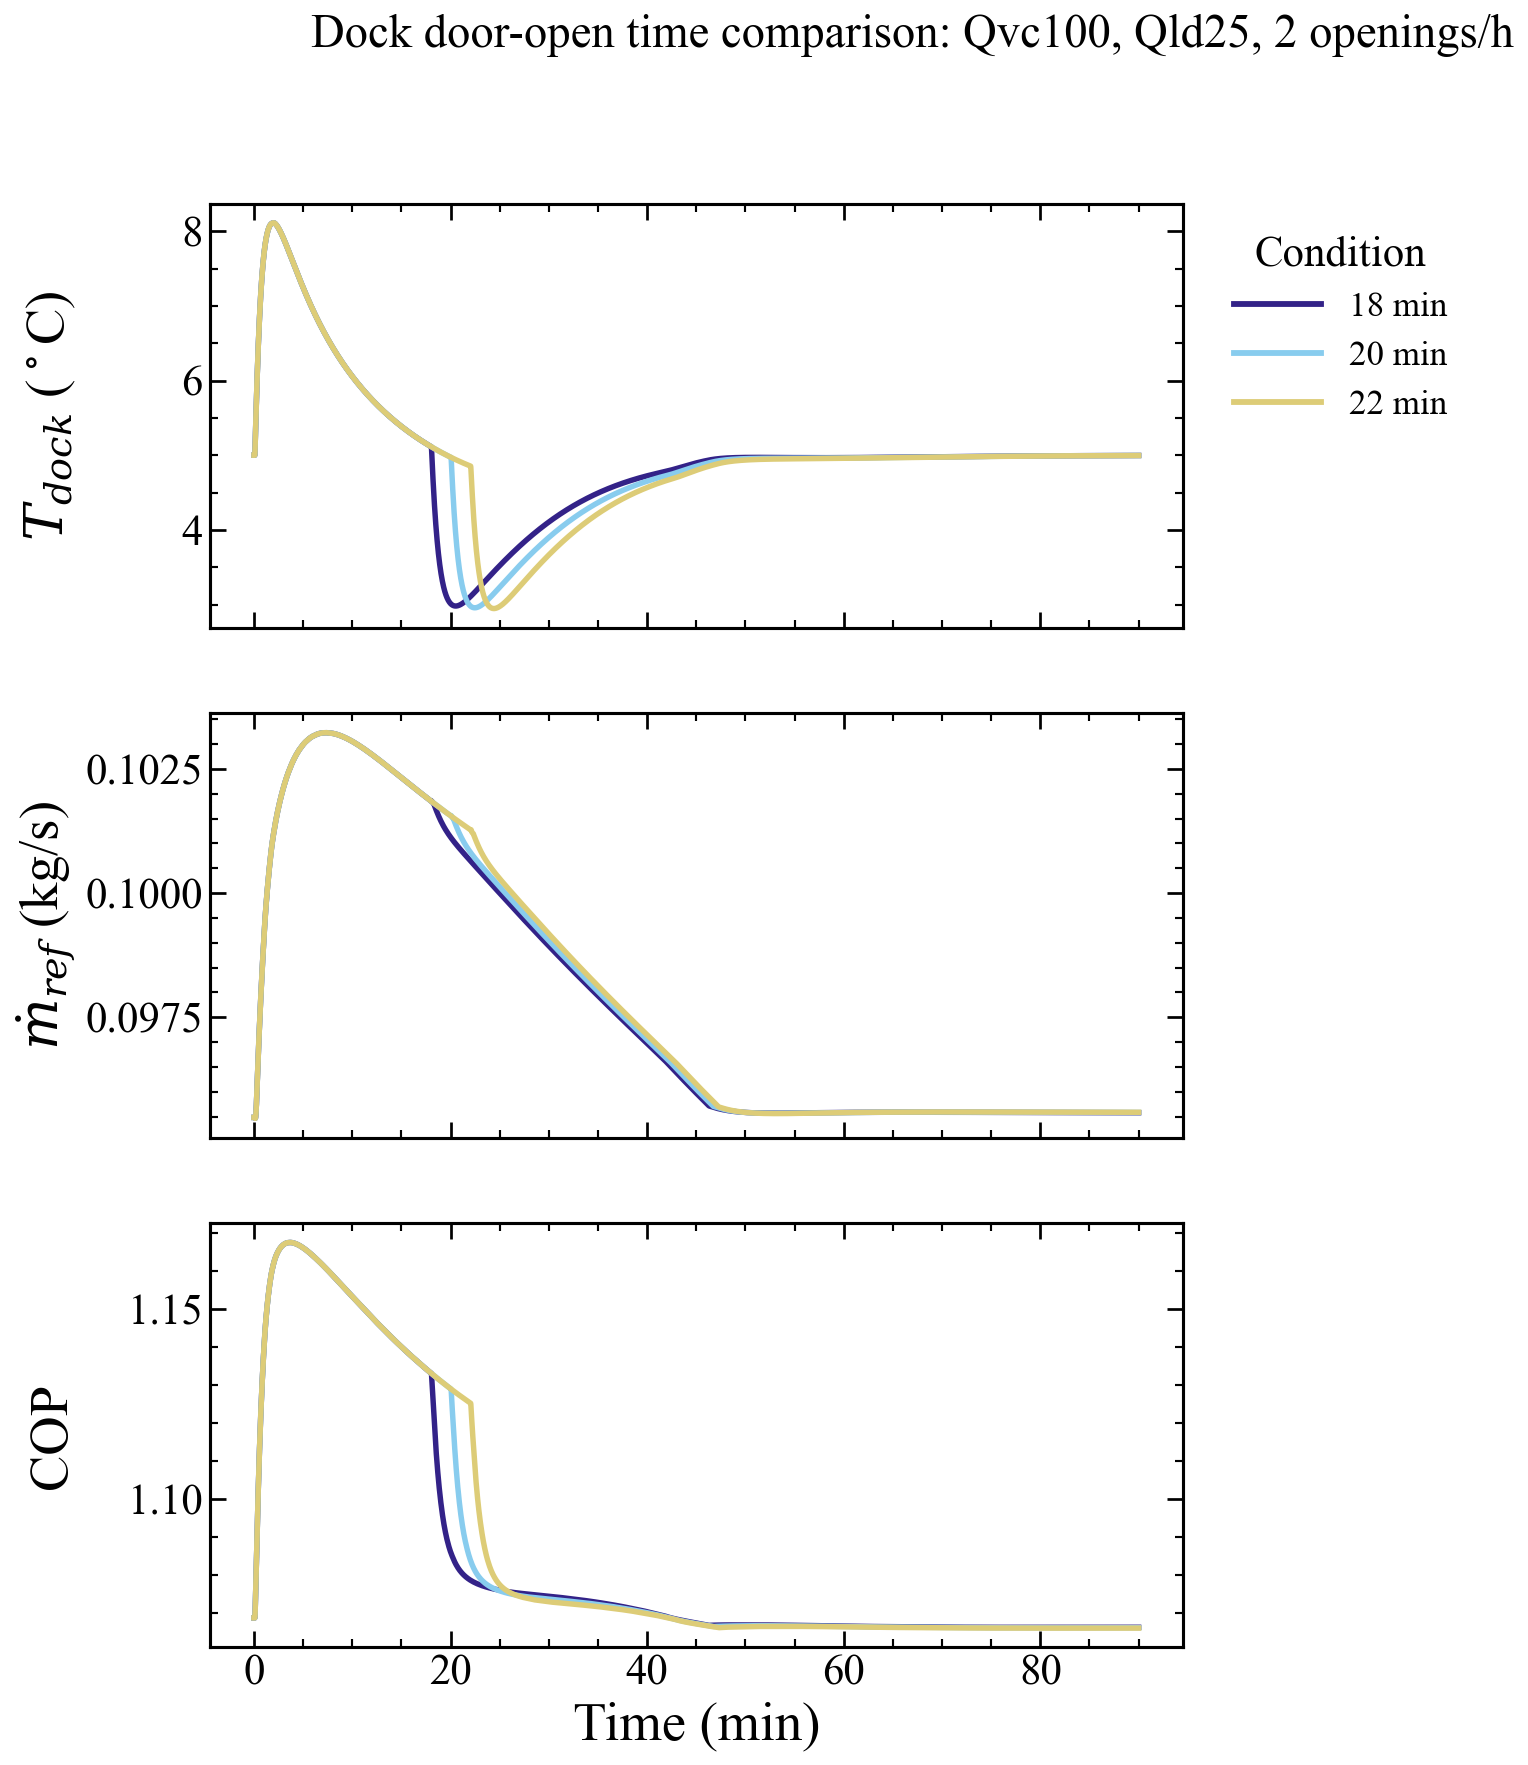

In [20]:
dock_door_time_cases = select_cases(space="LD", qvc=100, qld=25, openings_per_hour=2)
dock_door_time_cases = dock_door_time_cases[
    dock_door_time_cases["door_open_s"].isin([1080, 1200, 1320])
]

display(dock_door_time_cases[["space", "qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_comparison(
    dock_door_time_cases,
    label_func=lambda case: f"{int(case['door_open_s'] / 60)} min",
    title="Dock door-open time comparison: Qvc100, Qld25, 2 openings/h",
    save_name="comparison_dock_door_open_time_Qvc100_Qld25_2openings.png",
    colors=comparison_palettes["dock_door_time"],
    plot_columns=DOCK_PLOT_COLUMNS,
)


## 4. Qvc/Qld Load Variation

Compare available Qvc/Qld cases using 4 door openings per hour and 12 s door-open time.


,qvc,qld,openings_per_hour,door_open_s,path
6,100.0,15.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
9,100.0,20.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...
15,100.0,25.0,4,12,c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic...


Saved c:\Users\adlan\Downloads\Cascade_VC-AC_Dynamic\outputs\comparison_plots\comparison_Qvc_Qld_4openings_12s.png


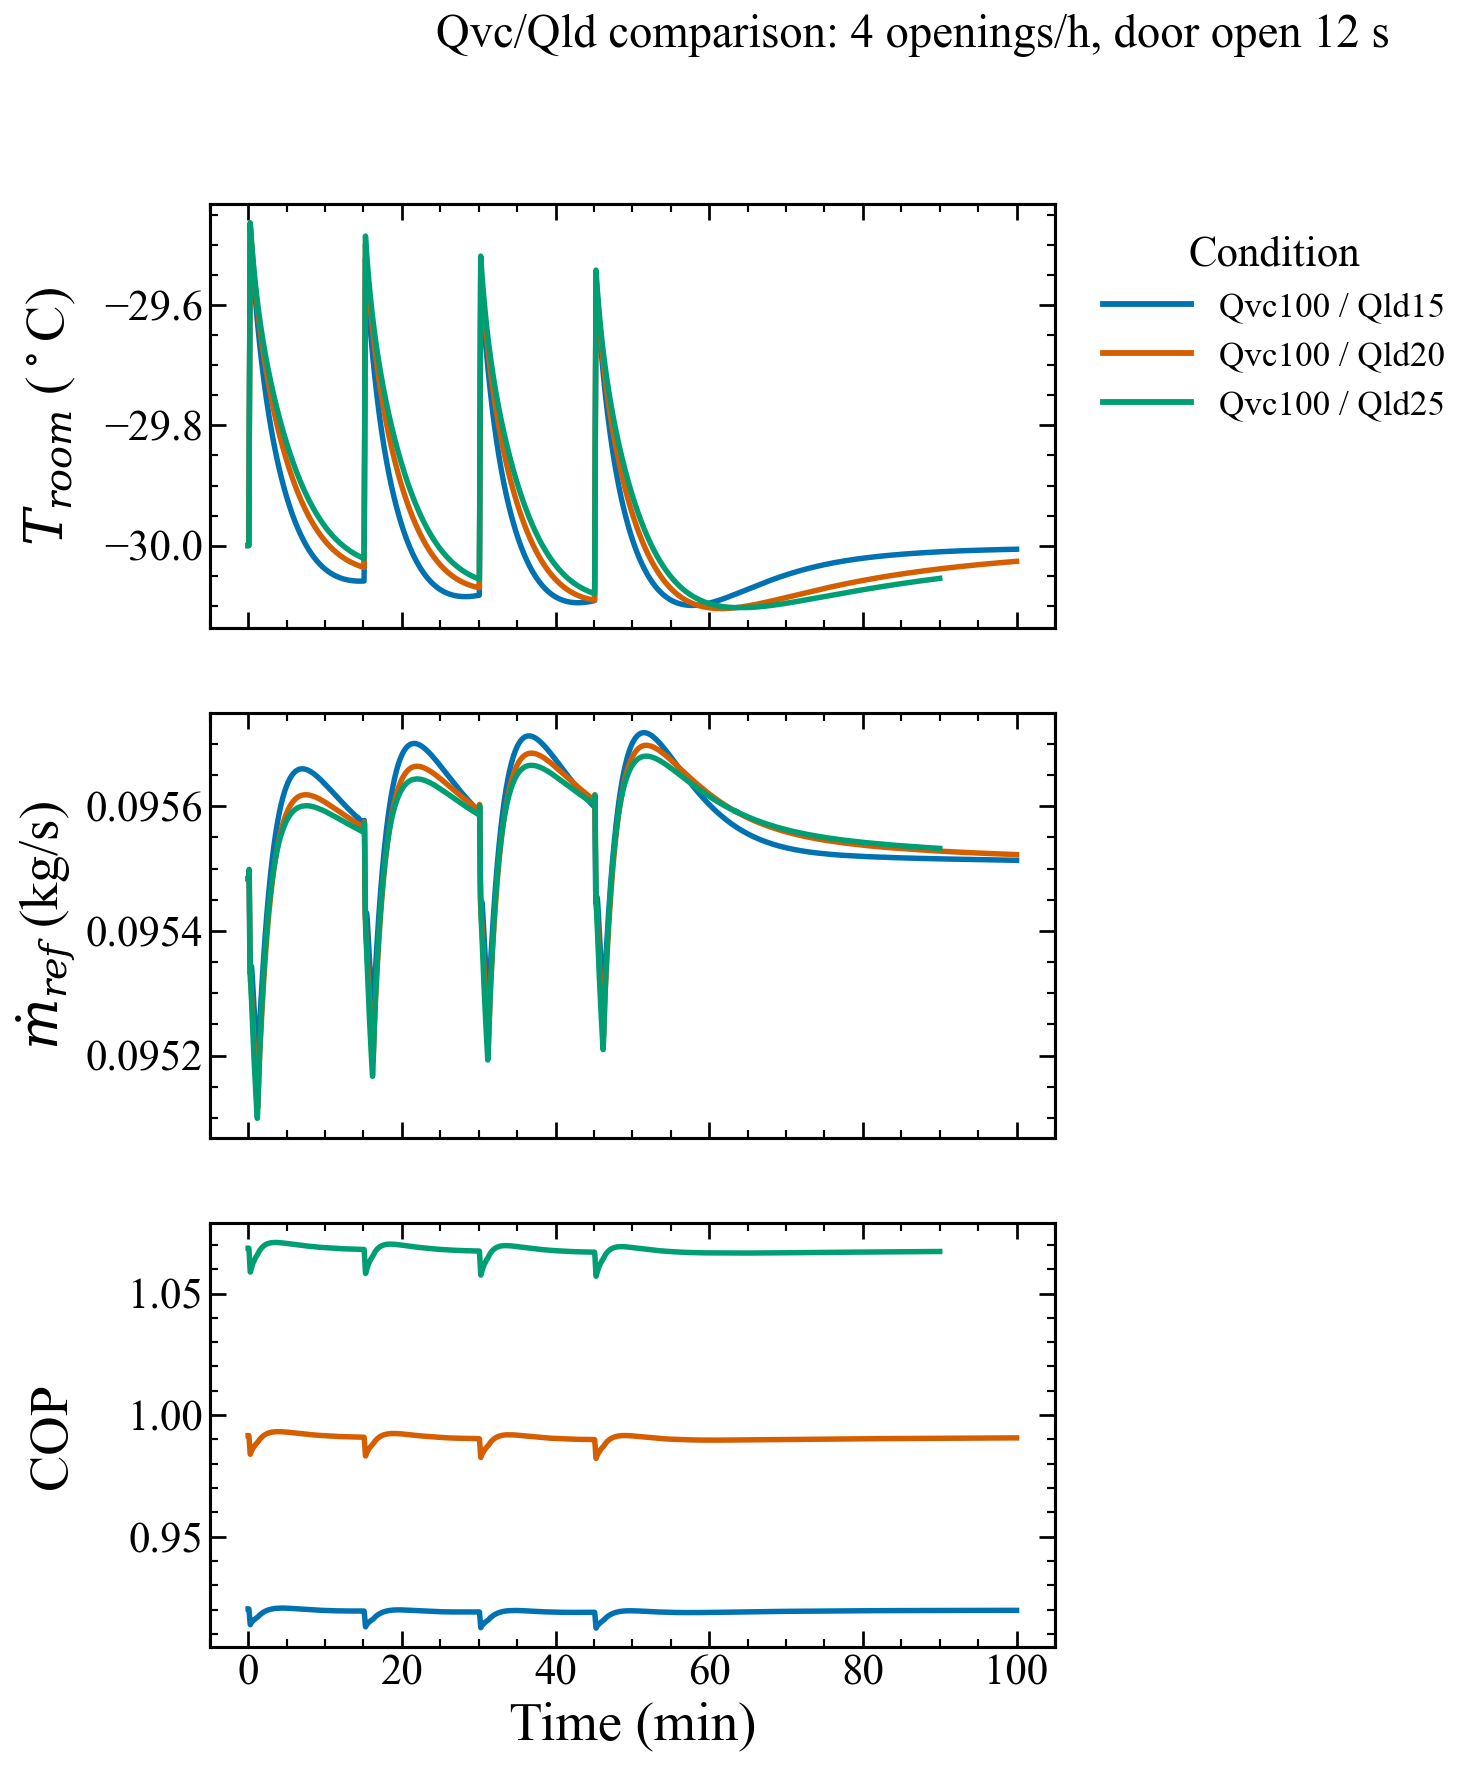

In [21]:
load_cases = select_cases(openings_per_hour=4, door_open_s=12)
load_cases = load_cases[load_cases["qld"].isin([15, 20, 25])]

display(load_cases[["qvc", "qld", "openings_per_hour", "door_open_s", "path"]])

plot_timeseries_comparison(
    load_cases,
    label_func=lambda case: f"Qvc{format_load(case['qvc'])} / Qld{format_load(case['qld'])}",
    title="Qvc/Qld comparison: 4 openings/h, door open 12 s",
    save_name="comparison_Qvc_Qld_4openings_12s.png",
    colors=comparison_palettes["load"],
)
